In [1]:
import datetime
print(f" Notebook last run (end-to-end) {datetime.datetime.now}")

 Notebook last run (end-to-end) <built-in method now of type object at 0x00007FF878C26650>


In [2]:
data_dir=r"C:\Users\venka\Downloads\pubmed-rct-master\pubmed-rct-master\PubMed_20k_RCT_numbers_replaced_with_at_sign"

In [3]:
import os 
for dirnames,dirpath,filenames in os.walk(data_dir):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")

There are 105 directories and 3 images in []


In [4]:
for names in os.walk(data_dir):
    print(names)

('C:\\Users\\venka\\Downloads\\pubmed-rct-master\\pubmed-rct-master\\PubMed_20k_RCT_numbers_replaced_with_at_sign', [], ['dev.txt', 'test.txt', 'train.txt'])


In [5]:
import os
filenames = [data_dir + filename for filename in os.listdir(data_dir)]
filenames

['C:\\Users\\venka\\Downloads\\pubmed-rct-master\\pubmed-rct-master\\PubMed_20k_RCT_numbers_replaced_with_at_signdev.txt',
 'C:\\Users\\venka\\Downloads\\pubmed-rct-master\\pubmed-rct-master\\PubMed_20k_RCT_numbers_replaced_with_at_signtest.txt',
 'C:\\Users\\venka\\Downloads\\pubmed-rct-master\\pubmed-rct-master\\PubMed_20k_RCT_numbers_replaced_with_at_signtrain.txt']

In [6]:
def get_lines(filename):
    with open(filename, 'r') as f:
        return f.readlines()

In [7]:
train_lines = get_lines(r"C:\Users\venka\Downloads\pubmed-rct-master\pubmed-rct-master\PubMed_20k_RCT_numbers_replaced_with_at_sign\train.txt")
train_lines[:20]

['###24293578\n',
 'OBJECTIVE\tTo investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .\n',
 'METHODS\tA total of @ patients with primary knee OA were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .\n',
 'METHODS\tOutcome measures included pain reduction and improvement in function scores and systemic inflammation markers .\n',
 'METHODS\tPain was assessed using the visual analog pain scale ( @-@ mm ) .\n',
 'METHODS\tSecondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores , patient global assessment ( PGA ) of the severity of knee OA , and @-min walk distance ( @MWD ) .\n',
 'METHODS\tSerum levels of interleukin @ ( IL-@ ) , IL-@ , tumor necrosis factor ( TNF ) - , and 

In [8]:
def preprocessing_text_with_line_numbers(filename):
    input_lines = get_lines(filename)
    abstract_lines = ""
    abstract_samples = []

    for line in input_lines:
        if line.startswith("###"):
            abstract_id = line
            abstract_lines = ""
        elif line.isspace():
            abstract_line_split = abstract_lines.splitlines()


            for abstract_line_number, abstract_line in enumerate(abstract_line_split):
                line_data = {}
                target_text_split = abstract_line.split("\t")
                line_data["target"] = target_text_split[0]
                line_data["text"] = target_text_split[1].lower()
                line_data["line_number"] = abstract_line_number
                line_data["total_lines"] = len(abstract_line_split) - 1
                abstract_samples.append(line_data)

        else:
            abstract_lines += line

    return abstract_samples




In [9]:
%%time
train_samples = preprocessing_text_with_line_numbers(
    r"C:\Users\venka\Downloads\pubmed-rct-master\pubmed-rct-master\PubMed_20k_RCT_numbers_replaced_with_at_sign\train.txt"
)

val_samples = preprocessing_text_with_line_numbers(
    r"C:\Users\venka\Downloads\pubmed-rct-master\pubmed-rct-master\PubMed_20k_RCT_numbers_replaced_with_at_sign\dev.txt"
)

test_samples = preprocessing_text_with_line_numbers(
    r"C:\Users\venka\Downloads\pubmed-rct-master\pubmed-rct-master\PubMed_20k_RCT_numbers_replaced_with_at_sign\test.txt"
)

len(train_samples), len(val_samples), len(test_samples)

CPU times: total: 406 ms
Wall time: 409 ms


(180040, 30212, 30135)

In [10]:
train_samples[:14]

[{'target': 'OBJECTIVE',
  'text': 'to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
  'line_number': 0,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
  'line_number': 1,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
  'line_number': 2,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
  'line_number': 3,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'secondary outcome measures included the western ontari

In [11]:
import pandas as pd 
train_df = pd.DataFrame(train_samples)
val_df = pd.DataFrame(val_samples)
test_df = pd.DataFrame(test_samples)
print(train_df)

             target                                               text  \
0         OBJECTIVE  to investigate the efficacy of @ weeks of dail...   
1           METHODS  a total of @ patients with primary knee oa wer...   
2           METHODS  outcome measures included pain reduction and i...   
3           METHODS  pain was assessed using the visual analog pain...   
4           METHODS  secondary outcome measures included the wester...   
...             ...                                                ...   
180035      RESULTS  for the absolute change in percent atheroma vo...   
180036      RESULTS  for pav , a significantly greater percentage o...   
180037      RESULTS  both strategies had acceptable side effect pro...   
180038  CONCLUSIONS  compared with standard statin monotherapy , th...   
180039  CONCLUSIONS  ( plaque regression with cholesterol absorptio...   

        line_number  total_lines  
0                 0           11  
1                 1           11  
2     

In [12]:
train_df.target.value_counts()

target
METHODS        59353
RESULTS        57953
CONCLUSIONS    27168
BACKGROUND     21727
OBJECTIVE      13839
Name: count, dtype: int64

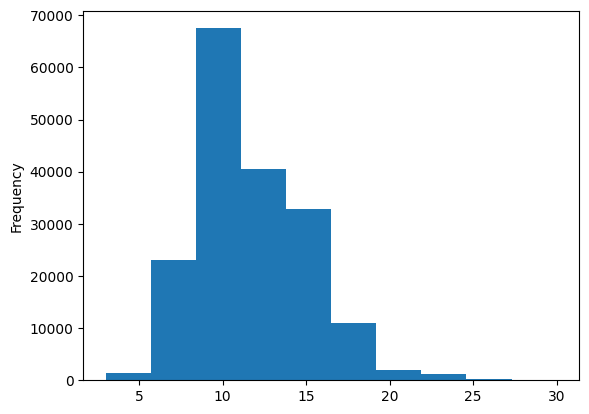

In [13]:
train_df.total_lines.plot.hist();